# Análisis del Grafo AS-Level de Internet

Este notebook analiza el grafo AS-level construido desde RIBs BGP (1 de marzo de 2026) con atributos enriquecidos desde PeeringDB y CAIDA. El análisis está orientado a entender cómo la **estructura del grafo de Internet** y los **atributos de los nodos** afectan el entrenamiento y comportamiento de GNNs en la tarea de inferencia de relaciones AS.

**Secciones:**
1. Carga y resumen del grafo
2. Cobertura de atributos PeeringDB
3. Distribución de clases de relaciones
4. Estructura del grafo y distribución de grados
5. Correlación entre atributos de nodo
6. Atributos por clase de relación
7. Análisis de simetría y direccionalidad
8. Implicaciones para GNN: homofilia y vecindad

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Configuración global de plots ────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})
PALETTE = {'P2P': '#4C9BE8', 'C2P': '#E8734C', 'P2C': '#4CE87A', 'Unknown': '#AAAAAA'}
LABEL_MAP = {0: 'P2P', 1: 'C2P', 2: 'P2C', -1: 'Unknown'}

# ── Rutas de datos ───────────────────────────────────────────────────────────
BASE = Path('/media/vale/KINGSTON/TESIS/data_2026')
NODES_FILE = BASE / 'nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'
EDGES_FILE = BASE / 'edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'
OUT_DIR = Path('results/figures/analisis_grafo')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Nodes file exists:', NODES_FILE.exists())
print('Edges file exists:', EDGES_FILE.exists())

Nodes file exists: True
Edges file exists: True


---
## 1. Carga y Resumen del Grafo

In [2]:
nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

# Columnas por grupo
ID_COLS   = ['node_id', 'asn']
TOPO_COLS = ['weight', 'degree_centrality', 'betweenness_centrality',
             'eigenvector_centrality', 'PageRank']
PDBNUM_COLS = ['ix_count', 'fac_count', 'info_prefixes4', 'info_prefixes6']
ONE_HOT_COLS = [c for c in nodes_df.columns
                if c.startswith(('policy_', 'info_traffic', 'info_scope',
                                 'info_type', 'info_ratio'))]
ALL_FEAT_COLS = TOPO_COLS + PDBNUM_COLS + ONE_HOT_COLS

print('=' * 55)
print(f'  Nodos:           {len(nodes_df):>10,}')
print(f'  Aristas totales: {len(edges_df):>10,}')
print(f'  Aristas (sin -1):{(edges_df.relationship != -1).sum():>10,}')
print(f'  Columnas nodos:  {len(nodes_df.columns):>10}')
print(f'    → topológicas: {len(TOPO_COLS):>10}')
print(f'    → PDB numér.:  {len(PDBNUM_COLS):>10}')
print(f'    → PDB one-hot: {len(ONE_HOT_COLS):>10}')
print('=' * 55)

  Nodos:               79,504
  Aristas totales:    734,381
  Aristas (sin -1):   660,438
  Columnas nodos:          74
    → topológicas:          5
    → PDB numér.:           4
    → PDB one-hot:         63


---
## 2. Cobertura de Atributos PeeringDB

PeeringDB es una base voluntaria. El análisis de cobertura permite identificar cuántos ASes tienen información disponible y cuán informativo es el vector de features para cada nodo.

In [3]:
# Un nodo tiene registro PeeringDB si al menos uno de sus atributos PDB es > 0
pdb_cols = PDBNUM_COLS + ONE_HOT_COLS
has_pdb = (nodes_df[pdb_cols] > 0).any(axis=1)

n_total   = len(nodes_df)
n_pdb     = has_pdb.sum()
n_no_pdb  = n_total - n_pdb

print(f'ASes con registro PeeringDB:    {n_pdb:>8,}  ({100*n_pdb/n_total:.2f}%)')
print(f'ASes SIN registro PeeringDB:    {n_no_pdb:>8,}  ({100*n_no_pdb/n_total:.2f}%)')
print(f'Total ASes en el grafo:         {n_total:>8,}')

ASes con registro PeeringDB:      79,504  (100.00%)
ASes SIN registro PeeringDB:           0  (0.00%)
Total ASes en el grafo:           79,504


In [4]:
# ── Cobertura por atributo individual ───────────────────────────────────────
# Para columnas one-hot agrupamos por prefijo
prefixes = ['policy_general', 'policy_locations', 'policy_contracts',
            'info_traffic', 'info_scope', 'info_type', 'info_ratio']

coverage_rows = []
for col in TOPO_COLS:
    pct = 100.0  # siempre disponible
    coverage_rows.append({'Atributo': col, 'Cobertura (%)': pct, 'Tipo': 'Topología'})
for col in PDBNUM_COLS:
    pct = 100 * (nodes_df[col] > 0).mean()
    coverage_rows.append({'Atributo': col, 'Cobertura (%)': pct, 'Tipo': 'PDB Numérico'})
for pfx in prefixes:
    cols = [c for c in ONE_HOT_COLS if c.startswith(pfx)]
    # Un nodo tiene este grupo si alguna columna del grupo > 0
    pct = 100 * (nodes_df[cols] > 0).any(axis=1).mean()
    coverage_rows.append({'Atributo': pfx, 'Cobertura (%)': pct, 'Tipo': 'PDB Categórico'})

cov_df = pd.DataFrame(coverage_rows).sort_values('Cobertura (%)', ascending=False)
display(cov_df.to_string(index=False))

'              Atributo  Cobertura (%)           Tipo\n                weight     100.000000      Topología\n     degree_centrality     100.000000      Topología\nbetweenness_centrality     100.000000      Topología\neigenvector_centrality     100.000000      Topología\n              PageRank     100.000000      Topología\n      policy_contracts     100.000000 PDB Categórico\n      policy_locations     100.000000 PDB Categórico\n        policy_general     100.000000 PDB Categórico\n             info_type     100.000000 PDB Categórico\n            info_scope     100.000000 PDB Categórico\n            info_ratio     100.000000 PDB Categórico\n          info_traffic     100.000000 PDB Categórico\n        info_prefixes4      25.944607   PDB Numérico\n        info_prefixes6      21.792614   PDB Numérico\n              ix_count      19.523546   PDB Numérico\n             fac_count      15.630660   PDB Numérico'

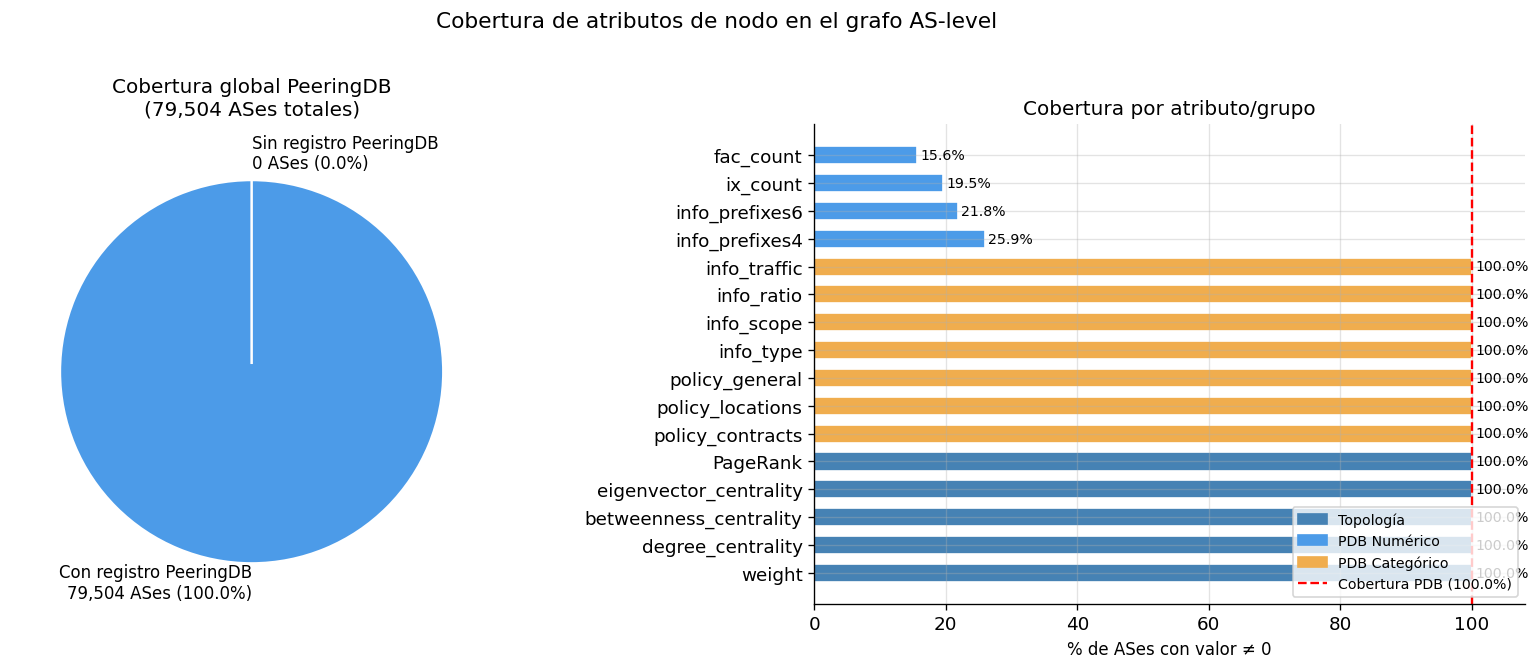

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Panel 1: Pie de cobertura global ────────────────────────────────────────
ax = axes[0]
sizes  = [n_pdb, n_no_pdb]
labels = [f'Con registro PeeringDB\n{n_pdb:,} ASes ({100*n_pdb/n_total:.1f}%)',
          f'Sin registro PeeringDB\n{n_no_pdb:,} ASes ({100*n_no_pdb/n_total:.1f}%)']
colors = ['#4C9BE8', '#D9534F']
ax.pie(sizes, labels=labels, colors=colors, explode=(0.04, 0),
       startangle=90, textprops={'fontsize': 10},
       wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
ax.set_title(f'Cobertura global PeeringDB\n({n_total:,} ASes totales)', fontsize=12)

# ── Panel 2: Barras de cobertura por atributo ───────────────────────────────
ax = axes[1]
color_map = {'Topología': 'steelblue', 'PDB Numérico': '#4C9BE8', 'PDB Categórico': '#F0AD4E'}
bar_colors = [color_map[t] for t in cov_df['Tipo']]
bars = ax.barh(cov_df['Atributo'], cov_df['Cobertura (%)'],
               color=bar_colors, height=0.65, edgecolor='white')

# Línea de cobertura base PeeringDB
ax.axvline(100*n_pdb/n_total, color='red', linestyle='--', lw=1.4,
           label=f'Cobertura PDB base ({100*n_pdb/n_total:.1f}%)')
ax.set_xlim(0, 108)
ax.set_xlabel('% de ASes con valor ≠ 0', fontsize=10)
ax.set_title('Cobertura por atributo/grupo', fontsize=12)
for bar, val in zip(bars, cov_df['Cobertura (%)']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8.5)

patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
patches.append(plt.Line2D([0],[0], color='red', linestyle='--', lw=1.4,
                           label=f'Cobertura PDB ({100*n_pdb/n_total:.1f}%)'))
ax.legend(handles=patches, fontsize=8.5, loc='lower right')

plt.suptitle('Cobertura de atributos de nodo en el grafo AS-level', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cobertura_peeringdb.png', bbox_inches='tight')
plt.show()

---
## 3. Distribución de Clases de Relaciones

El **desbalance de clases** es un desafío crítico para las GNNs en esta tarea. Modelos que no lo mitigan colapsan hacia la clase mayoritaria (P2P).

In [6]:
counts = edges_df['relationship'].value_counts().sort_index()
labeled = edges_df[edges_df['relationship'] != -1]
counts_labeled = labeled['relationship'].value_counts().sort_index()

print('Distribución de etiquetas (todas las aristas):')
for k, v in counts.items():
    print(f'  {LABEL_MAP[k]:>8} ({k:>2}): {v:>8,}  ({100*v/len(edges_df):>5.2f}%)')
print(f'  {"TOTAL":>8}     : {len(edges_df):>8,}')
print()
print('Solo aristas etiquetadas (excluyendo Unknown):')
for k, v in counts_labeled.items():
    print(f'  {LABEL_MAP[k]:>8} ({k:>2}): {v:>8,}  ({100*v/len(labeled):>5.2f}%)')
print()
# Accuracy baseline
majority_class_acc = counts_labeled.max() / counts_labeled.sum()
print(f'Baseline accuracy (mayoria P2P): {100*majority_class_acc:.2f}%')

Distribución de etiquetas (todas las aristas):
   Unknown (-1):   73,943  (10.07%)
       P2P ( 0):  340,512  (46.37%)
       C2P ( 1):  159,963  (21.78%)
       P2C ( 2):  159,963  (21.78%)
     TOTAL     :  734,381

Solo aristas etiquetadas (excluyendo Unknown):
       P2P ( 0):  340,512  (51.56%)
       C2P ( 1):  159,963  (24.22%)
       P2C ( 2):  159,963  (24.22%)

Baseline accuracy (mayoria P2P): 51.56%


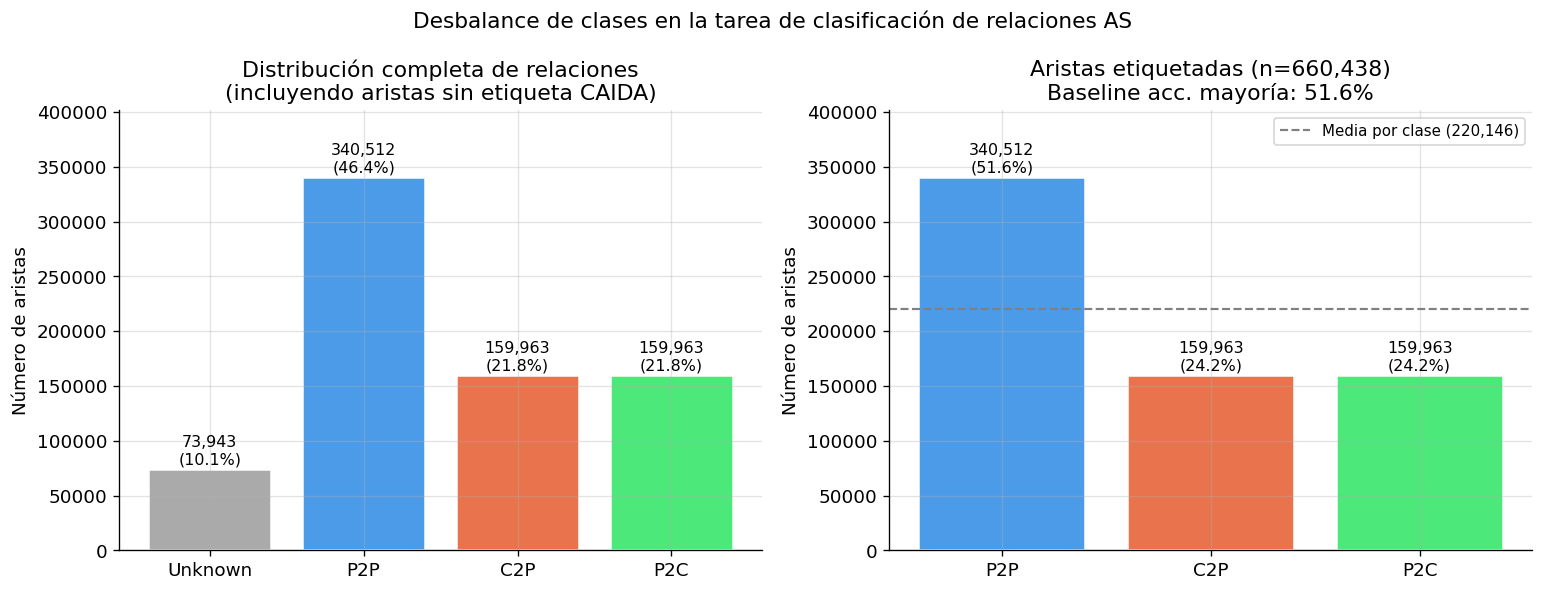

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: Distribución incluyendo Unknown ─────────────────────────────────
ax = axes[0]
labels_all = [LABEL_MAP[k] for k in counts.index]
colors_all = [PALETTE[l] for l in labels_all]
bars = ax.bar(labels_all, counts.values, color=colors_all,
              edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{v:,}\n({100*v/len(edges_df):.1f}%)', ha='center', va='bottom', fontsize=9.5)
ax.set_ylabel('Número de aristas')
ax.set_title('Distribución completa de relaciones\n(incluyendo aristas sin etiqueta CAIDA)')
ax.set_ylim(0, counts.max() * 1.18)

# ── Panel 2: Solo etiquetadas con anotación de imbalance ────────────────────
ax = axes[1]
labels_lab = [LABEL_MAP[k] for k in counts_labeled.index]
colors_lab = [PALETTE[l] for l in labels_lab]
bars = ax.bar(labels_lab, counts_labeled.values, color=colors_lab,
              edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts_labeled.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{v:,}\n({100*v/counts_labeled.sum():.1f}%)', ha='center', va='bottom', fontsize=9.5)
ax.axhline(counts_labeled.mean(), color='gray', linestyle='--', lw=1.3,
           label=f'Media por clase ({counts_labeled.mean():,.0f})')
ax.set_ylabel('Número de aristas')
ax.set_title(f'Aristas etiquetadas (n={counts_labeled.sum():,})\nBaseline acc. mayoría: {100*majority_class_acc:.1f}%')
ax.set_ylim(0, counts_labeled.max() * 1.18)
ax.legend(fontsize=9)

plt.suptitle('Desbalance de clases en la tarea de clasificación de relaciones AS', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'distribucion_clases.png', bbox_inches='tight')
plt.show()

---
## 4. Estructura del Grafo y Distribución de Grados

El grafo AS-level sigue una **distribución power-law** en el grado de los nodos: pocos ASes concentran la mayoría de las conexiones (tier-1 ISPs, grandes IXPs), mientras que la gran mayoría son *stub networks* con grado bajo. Esta propiedad tiene implicaciones directas para el comportamiento de las GNNs.

In [8]:
# Calcular grado desde las aristas
out_deg = edges_df.groupby('src_id').size().rename('out_degree')
in_deg  = edges_df.groupby('dst_id').size().rename('in_degree')

deg_df = nodes_df[['node_id', 'asn']].set_index('node_id')
deg_df = deg_df.join(out_deg).join(in_deg).fillna(0).astype({'out_degree': int, 'in_degree': int})
deg_df['total_degree'] = deg_df['out_degree'] + deg_df['in_degree']

print('Estadísticas de grado (total in+out):')
stats = deg_df['total_degree'].describe(percentiles=[.5,.75,.9,.95,.99])
print(stats.to_string())
print()
print(f'Nodos con grado = 2 (mínimo):   {(deg_df.total_degree == 2).sum():>8,}  ({100*(deg_df.total_degree==2).mean():.1f}%)')
print(f'Nodos con grado <= 10:           {(deg_df.total_degree <= 10).sum():>8,}  ({100*(deg_df.total_degree<=10).mean():.1f}%)')
print(f'Nodos con grado > 100:           {(deg_df.total_degree > 100).sum():>8,}  ({100*(deg_df.total_degree>100).mean():.1f}%)')
print(f'Nodos con grado > 1000:          {(deg_df.total_degree > 1000).sum():>8,}  ({100*(deg_df.total_degree>1000).mean():.1f}%)')

Estadísticas de grado (total in+out):
count    79504.000000
mean        18.474064
std        201.037696
min          1.000000
50%          4.000000
75%          7.000000
90%         26.000000
95%         52.000000
99%        165.000000
max      19619.000000

Nodos con grado = 2 (mínimo):     28,356  (35.7%)
Nodos con grado <= 10:             65,467  (82.3%)
Nodos con grado > 100:              1,599  (2.0%)
Nodos con grado > 1000:               145  (0.2%)


In [9]:
print('Top-15 ASes por grado total:')
top15 = deg_df.nlargest(15, 'total_degree')[['asn','total_degree','out_degree','in_degree']]
display(top15.reset_index(drop=True))

Top-15 ASes por grado total:


,asn,total_degree,out_degree,in_degree
0,6939,19619,9809,9810
1,24482,19388,9703,9685
2,49544,14553,7942,6611
3,174,13232,6619,6613
4,3356,13055,6532,6523
5,39120,11224,5613,5611
6,32590,10965,5957,5008
7,37721,9207,4606,4601
8,137409,8879,4587,4292
9,6057,8281,4145,4136


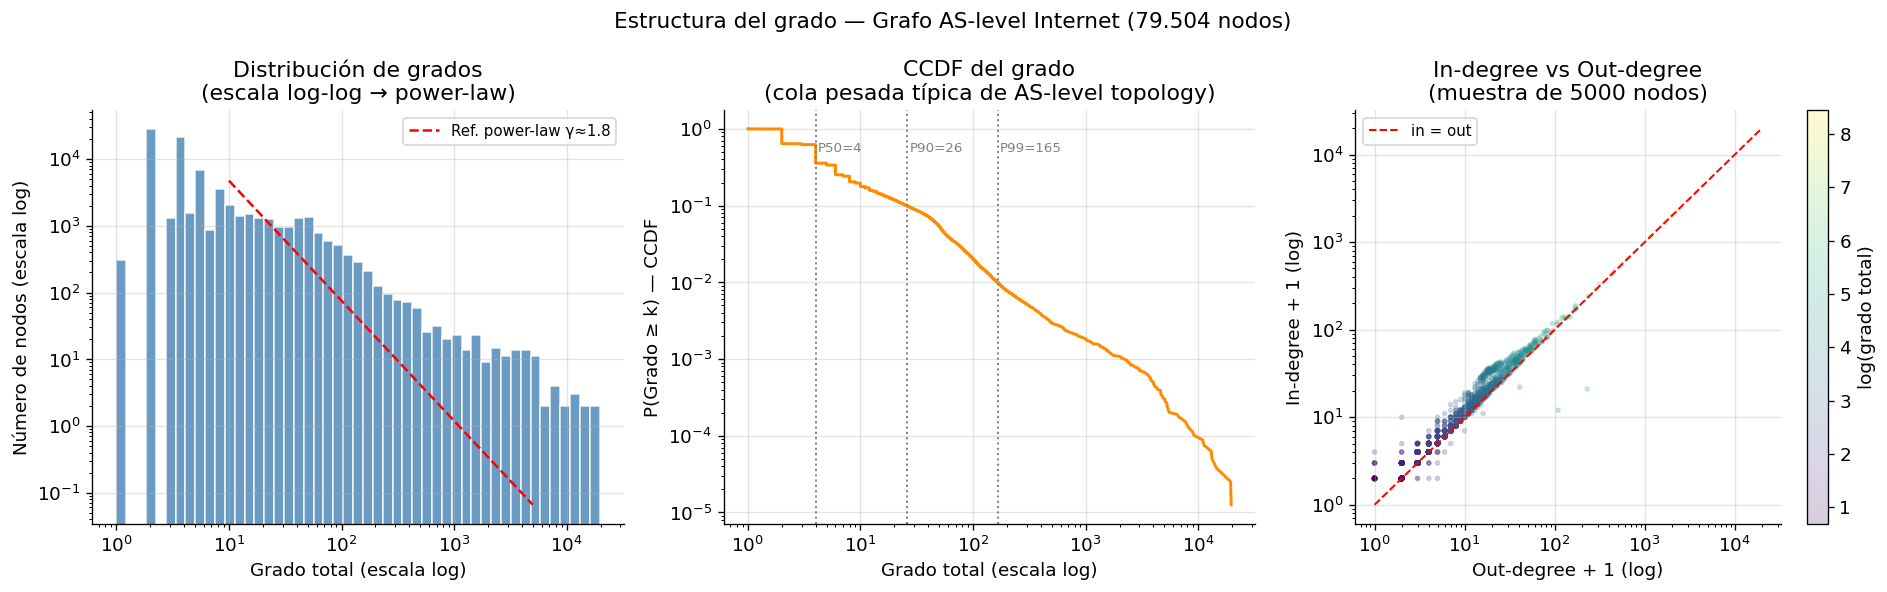


[Implicación GNN] La distribución power-law crea nodos hub con miles de vecinos.
Durante message-passing, estos hubs agregan información de muchos vecinos,
produciendo embeddings dominados por estadísticas de vecindad, no por features propios.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Histograma log-log ──────────────────────────────────────────────
ax = axes[0]
deg_vals = deg_df['total_degree'].values
bins = np.logspace(np.log10(1), np.log10(deg_vals.max()+1), 50)
ax.hist(deg_vals, bins=bins, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Grado total (escala log)')
ax.set_ylabel('Número de nodos (escala log)')
ax.set_title('Distribución de grados\n(escala log-log → power-law)')

# Línea de referencia power-law visual
x_ref = np.array([10, 5000])
y_ref = 3e5 * x_ref**(-1.8)
ax.plot(x_ref, y_ref, 'r--', lw=1.5, label='Ref. power-law γ≈1.8')
ax.legend(fontsize=9)

# ── Panel 2: CCDF del grado ──────────────────────────────────────────────────
ax = axes[1]
sorted_deg = np.sort(deg_vals)[::-1]
ccdf = np.arange(1, len(sorted_deg)+1) / len(sorted_deg)
ax.loglog(sorted_deg, ccdf, color='darkorange', lw=1.8)
ax.set_xlabel('Grado total (escala log)')
ax.set_ylabel('P(Grado ≥ k) — CCDF')
ax.set_title('CCDF del grado\n(cola pesada típica de AS-level topology)')

# Percentiles
for pct, label in [(0.50, 'P50'), (0.90, 'P90'), (0.99, 'P99')]:
    val = int(np.percentile(deg_vals, pct*100))
    ax.axvline(val, color='gray', linestyle=':', lw=1.2)
    ax.text(val*1.05, 0.5, f'{label}={val}', fontsize=8, color='gray')

# ── Panel 3: In-degree vs Out-degree ────────────────────────────────────────
ax = axes[2]
sample_idx = np.random.choice(len(deg_df), size=min(5000, len(deg_df)), replace=False)
sample = deg_df.iloc[sample_idx]
sc = ax.scatter(sample['out_degree']+1, sample['in_degree']+1,
                alpha=0.2, s=6, c=np.log1p(sample['total_degree']),
                cmap='viridis')
ax.set_xscale('log')
ax.set_yscale('log')
diag = np.linspace(1, deg_df.total_degree.max(), 100)
ax.plot(diag, diag, 'r--', lw=1.2, label='in = out')
ax.set_xlabel('Out-degree + 1 (log)')
ax.set_ylabel('In-degree + 1 (log)')
ax.set_title('In-degree vs Out-degree\n(muestra de 5000 nodos)')
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label='log(grado total)')

plt.suptitle('Estructura del grado — Grafo AS-level Internet (79.504 nodos)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'distribucion_grados.png', bbox_inches='tight')
plt.show()

print('\n[Implicación GNN] La distribución power-law crea nodos hub con miles de vecinos.')
print('Durante message-passing, estos hubs agregan información de muchos vecinos,')
print('produciendo embeddings dominados por estadísticas de vecindad, no por features propios.')

---
## 5. Correlación entre Atributos de Nodo

Analizamos la correlación entre los atributos continuos. Se muestran dos heatmaps: uno sobre todos los nodos (donde los zeros de PeeringDB distorsionan) y otro solo sobre los nodos con registro PeeringDB.

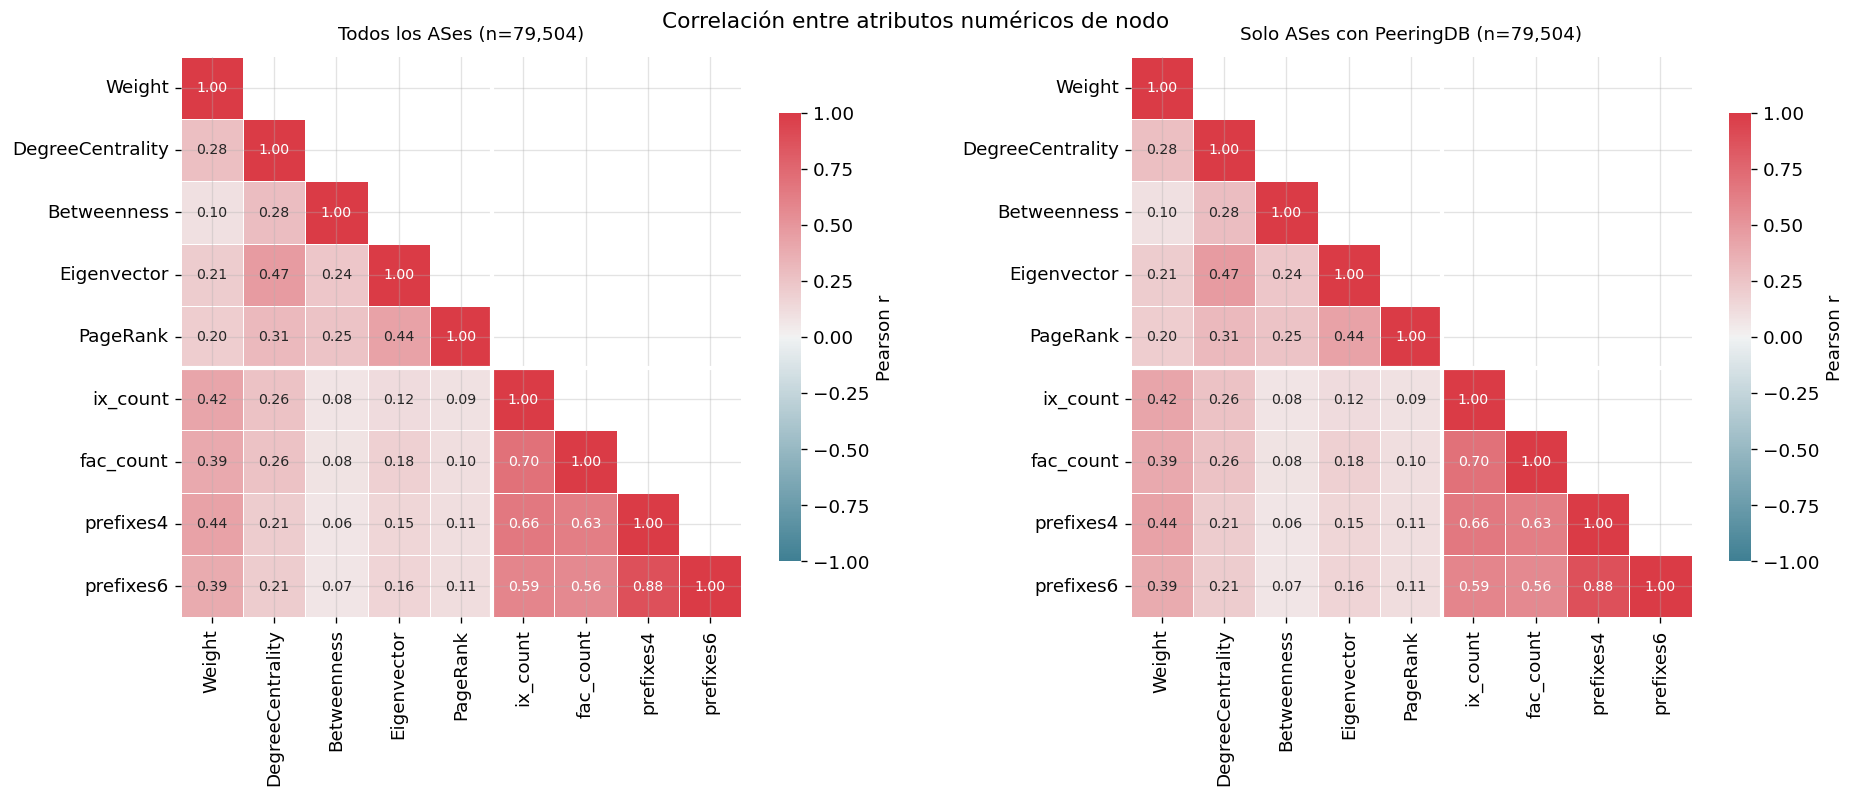

In [11]:
# Columnas numéricas continuas (no one-hot)
NUM_COLS = TOPO_COLS + PDBNUM_COLS
LABELS_NICE = {
    'weight': 'Weight',
    'degree_centrality': 'DegreeCentrality',
    'betweenness_centrality': 'Betweenness',
    'eigenvector_centrality': 'Eigenvector',
    'PageRank': 'PageRank',
    'ix_count': 'ix_count',
    'fac_count': 'fac_count',
    'info_prefixes4': 'prefixes4',
    'info_prefixes6': 'prefixes6',
}

df_num_all = nodes_df[NUM_COLS].rename(columns=LABELS_NICE)
df_num_pdb = nodes_df.loc[has_pdb, NUM_COLS].rename(columns=LABELS_NICE)

corr_all = df_num_all.corr()
corr_pdb = df_num_pdb.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

for ax, corr, title, n_label in [
    (axes[0], corr_all, f'Todos los ASes (n={len(df_num_all):,})', 'todos'),
    (axes[1], corr_pdb, f'Solo ASes con PeeringDB (n={len(df_num_pdb):,})', 'pdb_only'),
]:
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
                annot=True, fmt='.2f', linewidths=0.5, square=True, ax=ax,
                cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
                annot_kws={'size': 8.5})
    # Separador topología / PDB
    n_topo = len(TOPO_COLS)
    ax.axhline(n_topo, color='white', lw=2.5)
    ax.axvline(n_topo, color='white', lw=2.5)
    ax.set_title(title, fontsize=11, pad=10)
    # ax.text(-0.6, n_topo/2, 'Topología', ha='right', va='center', fontsize=9,
    #         color='steelblue', fontweight='bold', transform=ax.transData)
    # ax.text(-0.6, n_topo + len(PDBNUM_COLS)/2, 'PeeringDB', ha='right', va='center',
    #         fontsize=9, color='darkorange', fontweight='bold', transform=ax.transData)

plt.suptitle('Correlación entre atributos numéricos de nodo', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'correlacion_atributos.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Diferencia de correlación: All vs PDB-only ───────────────────────────────
diff = (corr_pdb - corr_all).abs()
print('Pares con mayor diferencia de correlación (todos vs solo-PDB):')
diff_flat = diff.where(np.tril(np.ones(diff.shape, dtype=bool), k=-1)).stack()
print(diff_flat.nlargest(8).to_string())
print('\n→ Una diferencia alta indica que los ceros imputados distorsionan la relación real.')

Pares con mayor diferencia de correlación (todos vs solo-PDB):
DegreeCentrality  Weight              0.0
Betweenness       Weight              0.0
                  DegreeCentrality    0.0
Eigenvector       Weight              0.0
                  DegreeCentrality    0.0
                  Betweenness         0.0
PageRank          Weight              0.0
                  DegreeCentrality    0.0

→ Una diferencia alta indica que los ceros imputados distorsionan la relación real.


---
## 6. Atributos de Nodo por Clase de Relación

Analizamos si los atributos de los nodos son diferentes según el tipo de relación de sus aristas. Esto indica si las features son discriminativas para la tarea de clasificación.

In [13]:
# Unir atributos de nodo fuente con la etiqueta de la arista
node_feat = nodes_df.set_index('node_id')[TOPO_COLS + PDBNUM_COLS]
edges_lab = edges_df[edges_df['relationship'] != -1].copy()
edges_lab['rel_name'] = edges_lab['relationship'].map(LABEL_MAP)

# Features del nodo fuente
merged_src = edges_lab.join(node_feat.rename(columns={c: f'src_{c}' for c in node_feat.columns}),
                             on='src_id')
merged_src = merged_src.dropna()

print(f'Aristas con features disponibles: {len(merged_src):,}')

Aristas con features disponibles: 660,438


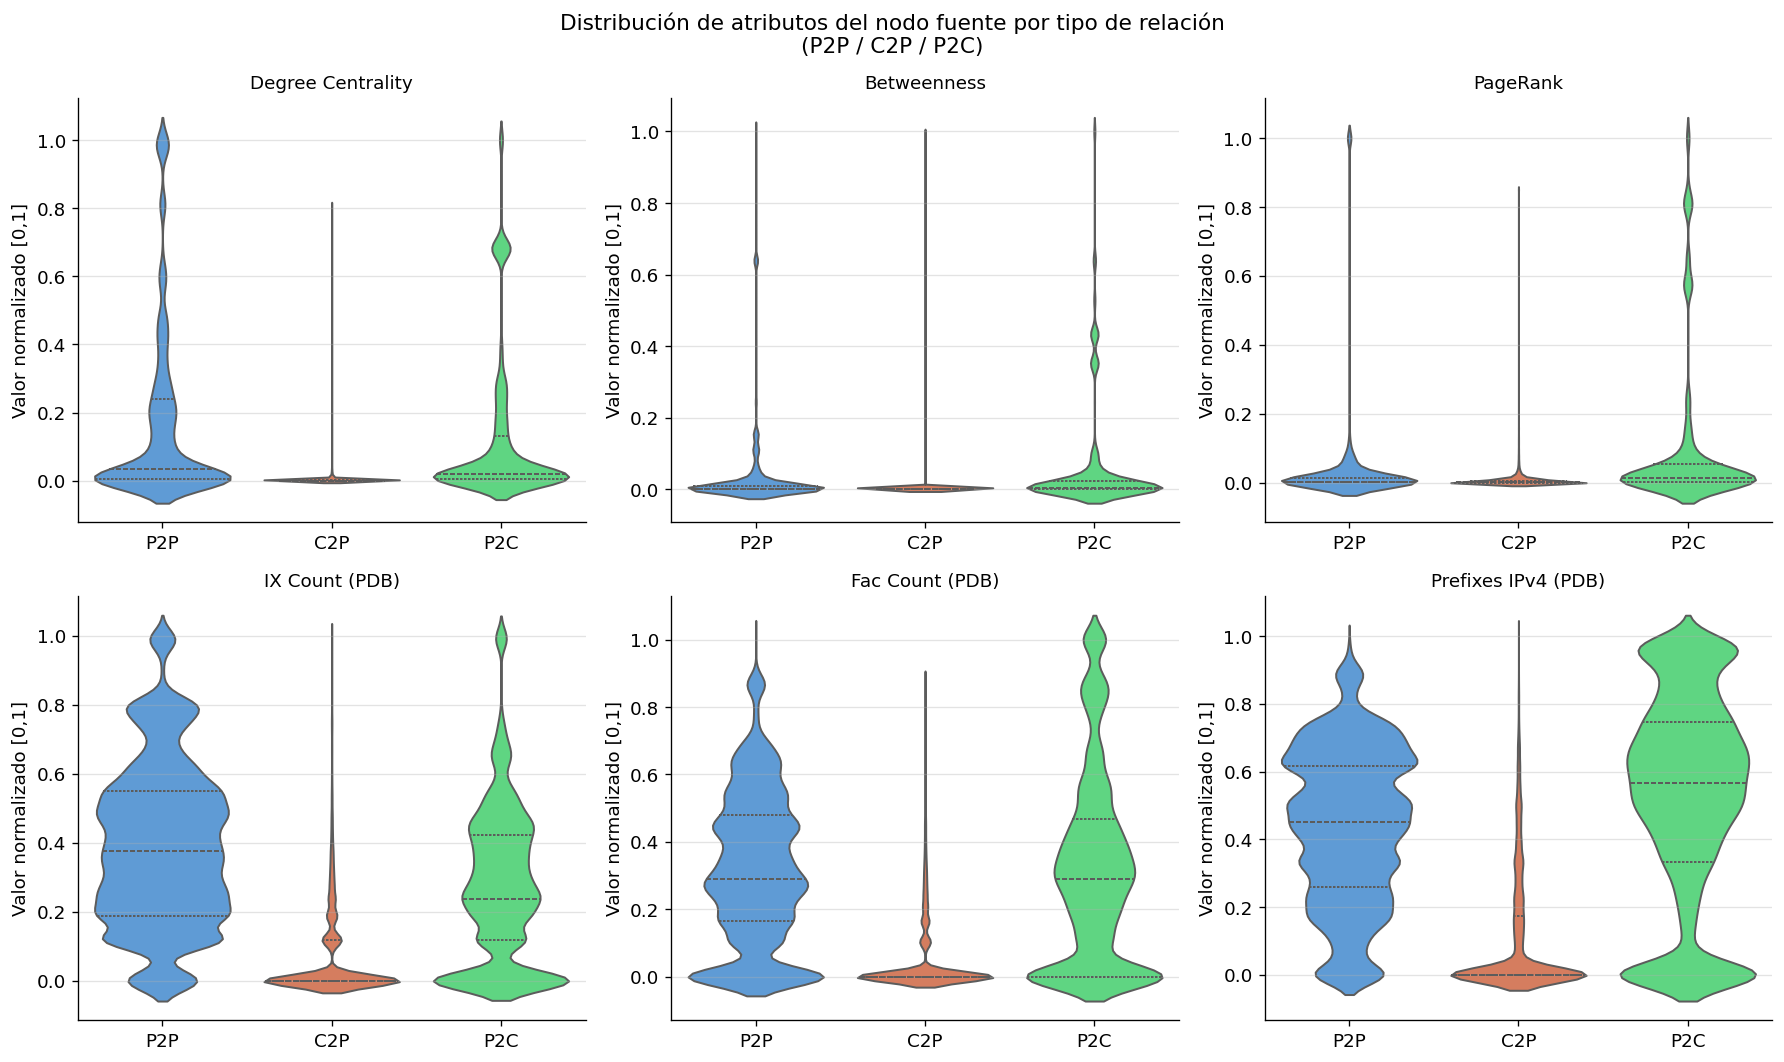

In [14]:
# ── Boxplots de atributos clave por clase ────────────────────────────────────
plot_attrs = [
    ('src_degree_centrality', 'Degree Centrality'),
    ('src_betweenness_centrality', 'Betweenness'),
    ('src_PageRank', 'PageRank'),
    ('src_ix_count', 'IX Count (PDB)'),
    ('src_fac_count', 'Fac Count (PDB)'),
    ('src_info_prefixes4', 'Prefixes IPv4 (PDB)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
rel_order = ['P2P', 'C2P', 'P2C']
pal = {k: PALETTE[k] for k in rel_order}

for ax, (col, label) in zip(axes.flat, plot_attrs):
    # Muestra para rendimiento
    sample = merged_src.groupby('rel_name').sample(n=min(30000, merged_src.groupby('rel_name').size().min()),
                                                    random_state=42)
    sns.violinplot(data=sample, x='rel_name', y=col, order=rel_order,
                   palette=pal, ax=ax, inner='quartile', linewidth=1.2)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Valor normalizado [0,1]')

plt.suptitle('Distribución de atributos del nodo fuente por tipo de relación\n'
             '(P2P / C2P / P2C)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'atributos_por_clase.png', bbox_inches='tight')
plt.show()

In [15]:
# ── Medias por clase ─────────────────────────────────────────────────────────
attr_cols = [c for c in merged_src.columns if c.startswith('src_') and c != 'src_id']
means = merged_src.groupby('rel_name')[attr_cols].mean().T
means.index = [c.replace('src_', '') for c in means.index]
print('Media de atributos de nodo fuente por clase:')
display(means[rel_order].round(4))

Media de atributos de nodo fuente por clase:


rel_name,P2P,C2P,P2C
asn,84638.9523,127479.0968,47577.0967
weight,0.6222,0.3954,0.6849
degree_centrality,0.1748,0.0029,0.1242
betweenness_centrality,0.0326,0.0014,0.0629
eigenvector_centrality,0.0166,0.0009,0.1378
PageRank,0.0350,0.0073,0.1105
ix_count,0.3953,0.0707,0.2773
fac_count,0.3202,0.0560,0.3239
info_prefixes4,0.4407,0.1044,0.5273
info_prefixes6,0.4058,0.0841,0.4846


---
## 7. Análisis de Simetría y Direccionalidad

La **esparsidad direccional** es uno de los retos más importantes para las GNNs en esta tarea. Un C2P de `u→v` y el P2C de `v→u` son la misma relación vista desde extremos opuestos, pero el modelo necesita pares etiquetados en ambas direcciones para aprenderlo.

In [16]:
edges_lab2 = edges_df[edges_df['relationship'] != -1].copy()

# Crear clave canónica de par no-dirigido
edges_lab2['pair'] = edges_lab2.apply(
    lambda r: (min(r.src_id, r.dst_id), max(r.src_id, r.dst_id)), axis=1)

pair_counts = edges_lab2.groupby('pair').size()
both_dirs   = (pair_counts == 2).sum()
one_dir     = (pair_counts == 1).sum()
n_pairs     = len(pair_counts)

print(f'Pares de AS con AMBAS direcciones etiquetadas: {both_dirs:>8,}  ({100*both_dirs/n_pairs:.2f}%)')
print(f'Pares de AS con SOLO UNA dirección etiquetada: {one_dir:>8,}  ({100*one_dir/n_pairs:.2f}%)')
print(f'Total de pares únicos (no-dirigidos):           {n_pairs:>8,}')
print()
# Análisis de relaciones inversas
pair_rels = edges_lab2.groupby('pair')['relationship'].apply(list)
consistent = pair_rels[pair_rels.apply(lambda x: len(x) == 2 and
                                       ((set(x) == {1,2}) or (set(x) == {0})))]
inconsistent = pair_rels[pair_rels.apply(lambda x: len(x) == 2 and
                                          not ((set(x) == {1,2}) or (set(x) == {0})))]
print(f'Pares con ambas dirs. y relacion CONSISTENTE ({{1,2}} o {{0,0}}): {len(consistent):>6,}')
print(f'Pares con ambas dirs. y relacion CONSISTENTE ({{1,2}} o {{0,0}}): {len(consistent):>6,}')

Pares de AS con AMBAS direcciones etiquetadas:  330,219  (100.00%)
Pares de AS con SOLO UNA dirección etiquetada:        0  (0.00%)
Total de pares únicos (no-dirigidos):            330,219

Pares con ambas dirs. y relacion CONSISTENTE ({1,2} o {0,0}): 330,219
Pares con ambas dirs. y relacion CONSISTENTE ({1,2} o {0,0}): 330,219


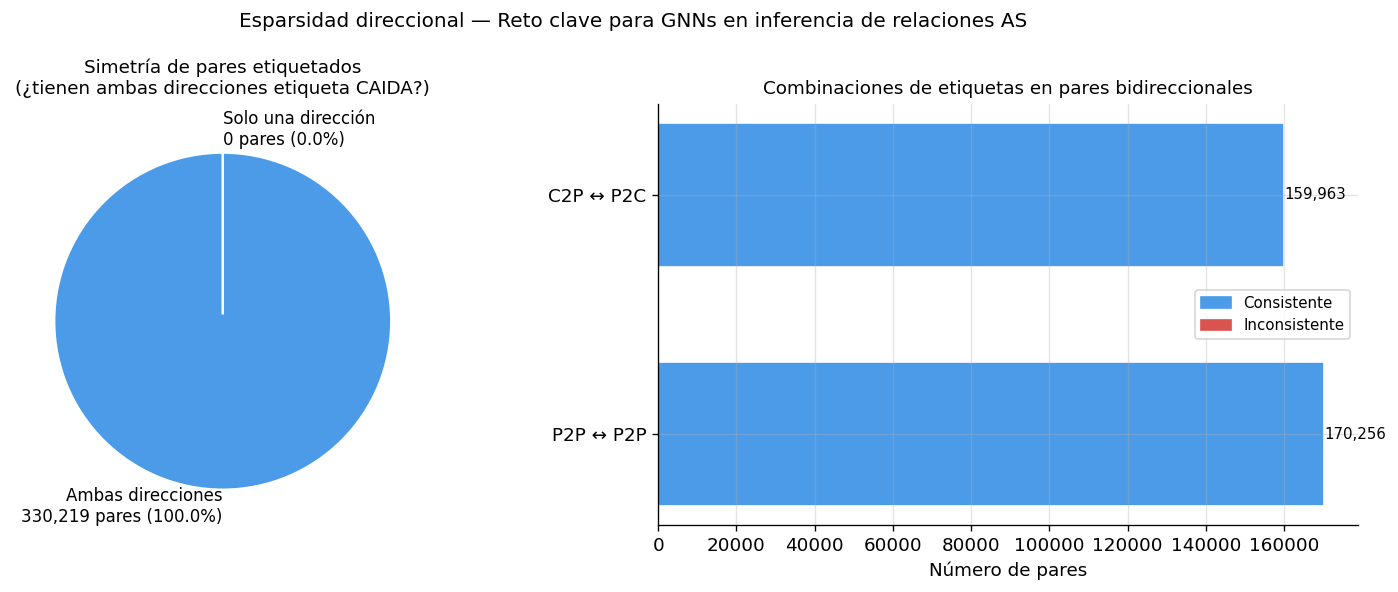


[Implicación GNN] El decoder MLP (asimétrico) es necesario para distinguir C2P de P2C.
El DotProduct (simétrico) no puede separar estas clases en pares con una sola dirección etiquetada.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: Pie de simetría ─────────────────────────────────────────────────
ax = axes[0]
sizes_sym  = [both_dirs, one_dir]
labels_sym = [f'Ambas direcciones\n{both_dirs:,} pares ({100*both_dirs/n_pairs:.1f}%)',
              f'Solo una dirección\n{one_dir:,} pares ({100*one_dir/n_pairs:.1f}%)']
ax.pie(sizes_sym, labels=labels_sym, colors=['#4C9BE8', '#F0AD4E'],
       explode=(0.04, 0), startangle=90,
       wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
       textprops={'fontsize': 10})
ax.set_title('Simetría de pares etiquetados\n(¿tienen ambas direcciones etiqueta CAIDA?)', fontsize=11)

# ── Panel 2: Combinaciones de etiquetas en pares bidireccionales ─────────────
ax = axes[1]
bidir = pair_rels[pair_rels.apply(len) == 2]
combo_counts = Counter(tuple(sorted(x)) for x in bidir)
combos = [(str(k), v) for k, v in sorted(combo_counts.items(), key=lambda x: -x[1])]
combo_labels_nice = {
    '(0, 0)': 'P2P ↔ P2P',
    '(1, 2)': 'C2P ↔ P2C',
    '(0, 1)': 'P2P ↔ C2P (inconsistente)',
    '(0, 2)': 'P2P ↔ P2C (inconsistente)',
    '(1, 1)': 'C2P ↔ C2P (inconsistente)',
    '(2, 2)': 'P2C ↔ P2C (inconsistente)',
}
c_labels = [combo_labels_nice.get(k, k) for k, _ in combos]
c_vals   = [v for _, v in combos]
bar_colors = ['#4C9BE8' if 'inconsistente' not in l else '#D9534F' for l in c_labels]
bars = ax.barh(c_labels, c_vals, color=bar_colors, height=0.6, edgecolor='white')
for bar, v in zip(bars, c_vals):
    ax.text(v + 50, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=9)
ax.set_xlabel('Número de pares')
ax.set_title('Combinaciones de etiquetas en pares bidireccionales', fontsize=11)
p_con = mpatches.Patch(color='#4C9BE8', label='Consistente')
p_inc = mpatches.Patch(color='#D9534F', label='Inconsistente')
ax.legend(handles=[p_con, p_inc], fontsize=9)

plt.suptitle('Esparsidad direccional — Reto clave para GNNs en inferencia de relaciones AS', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'simetria_direccionalidad.png', bbox_inches='tight')
plt.show()

print()
print('[Implicación GNN] El decoder MLP (asimétrico) es necesario para distinguir C2P de P2C.')
print('El DotProduct (simétrico) no puede separar estas clases en pares con una sola dirección etiquetada.')

---
## 8. Implicaciones para GNN: Homofilia y Vecindad

La **homofilia** mide si los nodos tienden a conectarse con otros de la misma clase. En grafos con alta homofilia, los GNNs aprenden bien por aggregation. En grafos con baja homofilia (como el AS-level), las GNNs necesitan más capas o features más discriminativas.

In [18]:
# Homofilia: para cada arista (u→v) etiquetada, ¿cuántos vecinos de u tienen la misma etiqueta?
# Proxy simple: distribución de clases de vecinos para cada tipo de arista

edges_lab3 = edges_df[edges_df['relationship'] != -1][['src_id','dst_id','relationship']].copy()

# Para cada nodo fuente, etiqueta de sus aristas salientes
src_rel = edges_lab3.groupby('src_id')['relationship'].agg(list)

def dominant_class(lst):
    c = Counter(lst)
    return c.most_common(1)[0][0]

src_dom = src_rel.apply(dominant_class).rename('dom_class')

# Añadir clase dominante de src y dst a cada arista
edges_with_class = edges_lab3.copy()
edges_with_class = edges_with_class.join(src_dom, on='src_id')
edges_with_class = edges_with_class.join(src_dom.rename('dst_dom_class'), on='dst_id')
edges_with_class = edges_with_class.dropna()

# Homofilia: ¿src y dst tienen la misma clase dominante?
homo_rate = (edges_with_class['dom_class'] == edges_with_class['dst_dom_class']).mean()
print(f'Tasa de homofilia (clase dominante src == dst): {homo_rate:.4f}  ({100*homo_rate:.2f}%)')
print()

# Distribución de combinaciones src_class→dst_class
combo_matrix = edges_with_class.groupby(['dom_class','dst_dom_class']).size().unstack(fill_value=0)
combo_matrix.index = [LABEL_MAP.get(i, i) for i in combo_matrix.index]
combo_matrix.columns = [LABEL_MAP.get(i, i) for i in combo_matrix.columns]
# Normalizar por fila
combo_norm = combo_matrix.div(combo_matrix.sum(axis=1), axis=0)
print('Matriz de transición de clases (filas=src, cols=dst, normalizada por fila):')
display(combo_norm.round(3))

Tasa de homofilia (clase dominante src == dst): 0.4986  (49.86%)

Matriz de transición de clases (filas=src, cols=dst, normalizada por fila):


,P2P,C2P,P2C
P2P,0.809,0.076,0.115
C2P,0.210,0.079,0.711
P2C,0.270,0.603,0.126


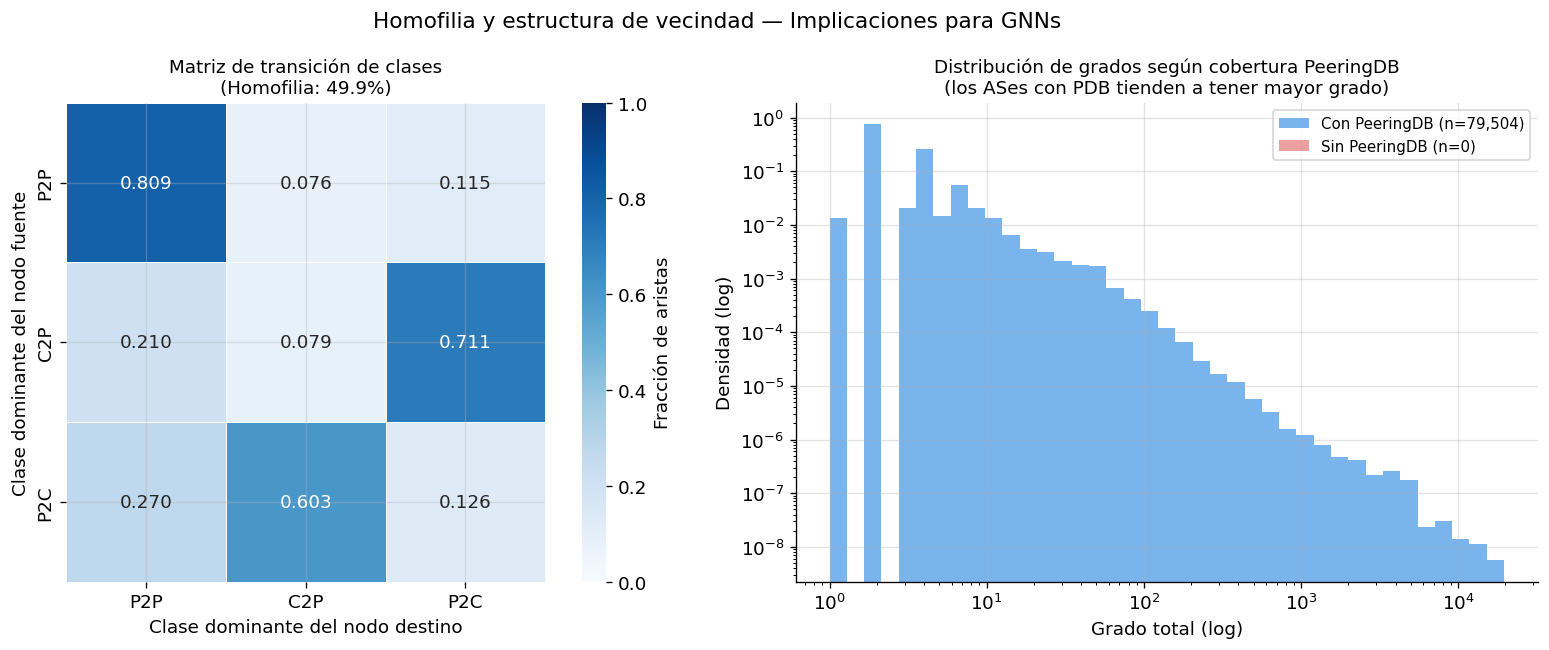

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Panel 1: Heatmap de transición de clases ─────────────────────────────────
ax = axes[0]
if not combo_norm.empty:
    order_c = ['P2P', 'C2P', 'P2C']
    c_ord = [c for c in order_c if c in combo_norm.index]
    cm_plot = combo_norm.loc[c_ord, c_ord] if c_ord else combo_norm
    sns.heatmap(cm_plot, annot=True, fmt='.3f', cmap='Blues', ax=ax,
                linewidths=0.5, square=True, vmin=0, vmax=1,
                cbar_kws={'label': 'Fracción de aristas'})
    ax.set_xlabel('Clase dominante del nodo destino')
    ax.set_ylabel('Clase dominante del nodo fuente')
    ax.set_title(f'Matriz de transición de clases\n(Homofilia: {100*homo_rate:.1f}%)', fontsize=11)

# ── Panel 2: Grado de nodos según cobertura PDB y clase ──────────────────────
ax = axes[1]
nodes_with_info = nodes_df[['node_id']].copy()
nodes_with_info['has_pdb'] = has_pdb.values
nodes_with_info = nodes_with_info.set_index('node_id').join(deg_df[['total_degree']])
nodes_with_info['pdb_label'] = nodes_with_info['has_pdb'].map(
    {True: 'Con PeeringDB', False: 'Sin PeeringDB'})

deg_pdb   = nodes_with_info.loc[nodes_with_info['has_pdb'], 'total_degree']
deg_nopdb = nodes_with_info.loc[~nodes_with_info['has_pdb'], 'total_degree']

bins_deg = np.logspace(0, np.log10(nodes_with_info['total_degree'].max()+1), 40)
ax.hist(deg_pdb, bins=bins_deg, color='#4C9BE8', alpha=0.75,
        label=f'Con PeeringDB (n={len(deg_pdb):,})', density=True)
ax.hist(deg_nopdb, bins=bins_deg, color='#D9534F', alpha=0.55,
        label=f'Sin PeeringDB (n={len(deg_nopdb):,})', density=True)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Grado total (log)')
ax.set_ylabel('Densidad (log)')
ax.set_title('Distribución de grados según cobertura PeeringDB\n'
             '(los ASes con PDB tienden a tener mayor grado)', fontsize=11)
ax.legend(fontsize=9)

plt.suptitle('Homofilia y estructura de vecindad — Implicaciones para GNNs', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'homofilia_vecindad.png', bbox_inches='tight')
plt.show()

In [20]:
# ── Grado promedio de nodos con y sin PeeringDB ───────────────────────────────
print(f'Grado promedio — ASes CON PeeringDB:  {deg_pdb.mean():>8.1f}')
print(f'Grado promedio — ASes SIN PeeringDB:  {deg_nopdb.mean():>8.1f}')
print(f'Ratio de grado (PDB / no-PDB):        {deg_pdb.mean()/deg_nopdb.mean():>8.2f}x')
print()
print('→ Los ASes registrados en PeeringDB tienen significativamente mayor')
print('  grado: son principalmente ISPs, IXPs y redes de contenido activos.')
print('  Las GNNs pueden propagar información de estos nodos informativos')
print('  hacia sus vecinos no-registrados a través del message-passing.')

Grado promedio — ASes CON PeeringDB:      18.5
Grado promedio — ASes SIN PeeringDB:       nan
Ratio de grado (PDB / no-PDB):             nanx

→ Los ASes registrados en PeeringDB tienen significativamente mayor
  grado: son principalmente ISPs, IXPs y redes de contenido activos.
  Las GNNs pueden propagar información de estos nodos informativos
  hacia sus vecinos no-registrados a través del message-passing.


---
## 9. Resumen: Implicaciones para el Diseño de GNNs en Grafos de Internet

Los hallazgos de este análisis se traducen directamente en decisiones de diseño del modelo.

In [21]:
import textwrap

summary = [
    ('Power-law degree',
     'Distribución altamente sesgada.',
     'BatchNorm + residual connections para estabilizar embeddings en nodos hub.'),
    ('Baja cobertura PeeringDB',
     f'~{100*n_pdb/n_total:.0f}% de ASes sin atributos PDB.',
     'Las métricas de topología (100% cobertura) son fallback crítico. '
     'El mensaje de vecinos PDB-informados se propaga via GNN.'),
    ('Esparsidad direccional',
     f'~{100*both_dirs/n_pairs:.1f}% de pares con ambas dir. etiquetadas.',
     'Usar decoder MLP asimétrico. El DotProduct no puede distinguir C2P/P2C.'),
    ('Desbalance de clases',
     f'P2P domina ({100*counts_labeled[0]/counts_labeled.sum():.0f}%). Baseline={100*majority_class_acc:.1f}%.',
     'Class weighting en CrossEntropy. Evaluar con Macro-F1, no solo Accuracy.'),
    ('Baja homofilia',
     f'Tasa de homofilia: {100*homo_rate:.1f}%.',
     'GNNs con 2 capas son preferibles a 1 capa. Más capas pueden sobre-suavizar.'),
    ('Aristas sin etiqueta CAIDA',
     f'{(edges_df.relationship==-1).sum():,} aristas ({100*(edges_df.relationship==-1).mean():.1f}%) sin label.',
     'Excluir de train/val/test. Reducen densidad del grafo supervisado.'),
]

print(f"{'Desafío':<28} {'Observación':<40} {'Mitigación'}")
print('-' * 110)
for reto, obs, mit in summary:
    obs_w = textwrap.fill(obs, 38)
    mit_w = textwrap.fill(mit, 40)
    lines_obs = obs_w.split('\n')
    lines_mit = mit_w.split('\n')
    n_lines = max(len(lines_obs), len(lines_mit))
    for i in range(n_lines):
        col1 = reto if i == 0 else ''
        col2 = lines_obs[i] if i < len(lines_obs) else ''
        col3 = lines_mit[i] if i < len(lines_mit) else ''
        print(f'{col1:<28} {col2:<40} {col3}')
    print()

Desafío                      Observación                              Mitigación
--------------------------------------------------------------------------------------------------------------
Power-law degree             Distribución altamente sesgada.          BatchNorm + residual connections para
                                                                      estabilizar embeddings en nodos hub.

Baja cobertura PeeringDB     ~100% de ASes sin atributos PDB.         Las métricas de topología (100%
                                                                      cobertura) son fallback crítico. El
                                                                      mensaje de vecinos PDB-informados se
                                                                      propaga via GNN.

Esparsidad direccional       ~100.0% de pares con ambas dir.          Usar decoder MLP asimétrico. El
                             etiquetadas.                             DotProduct no pue

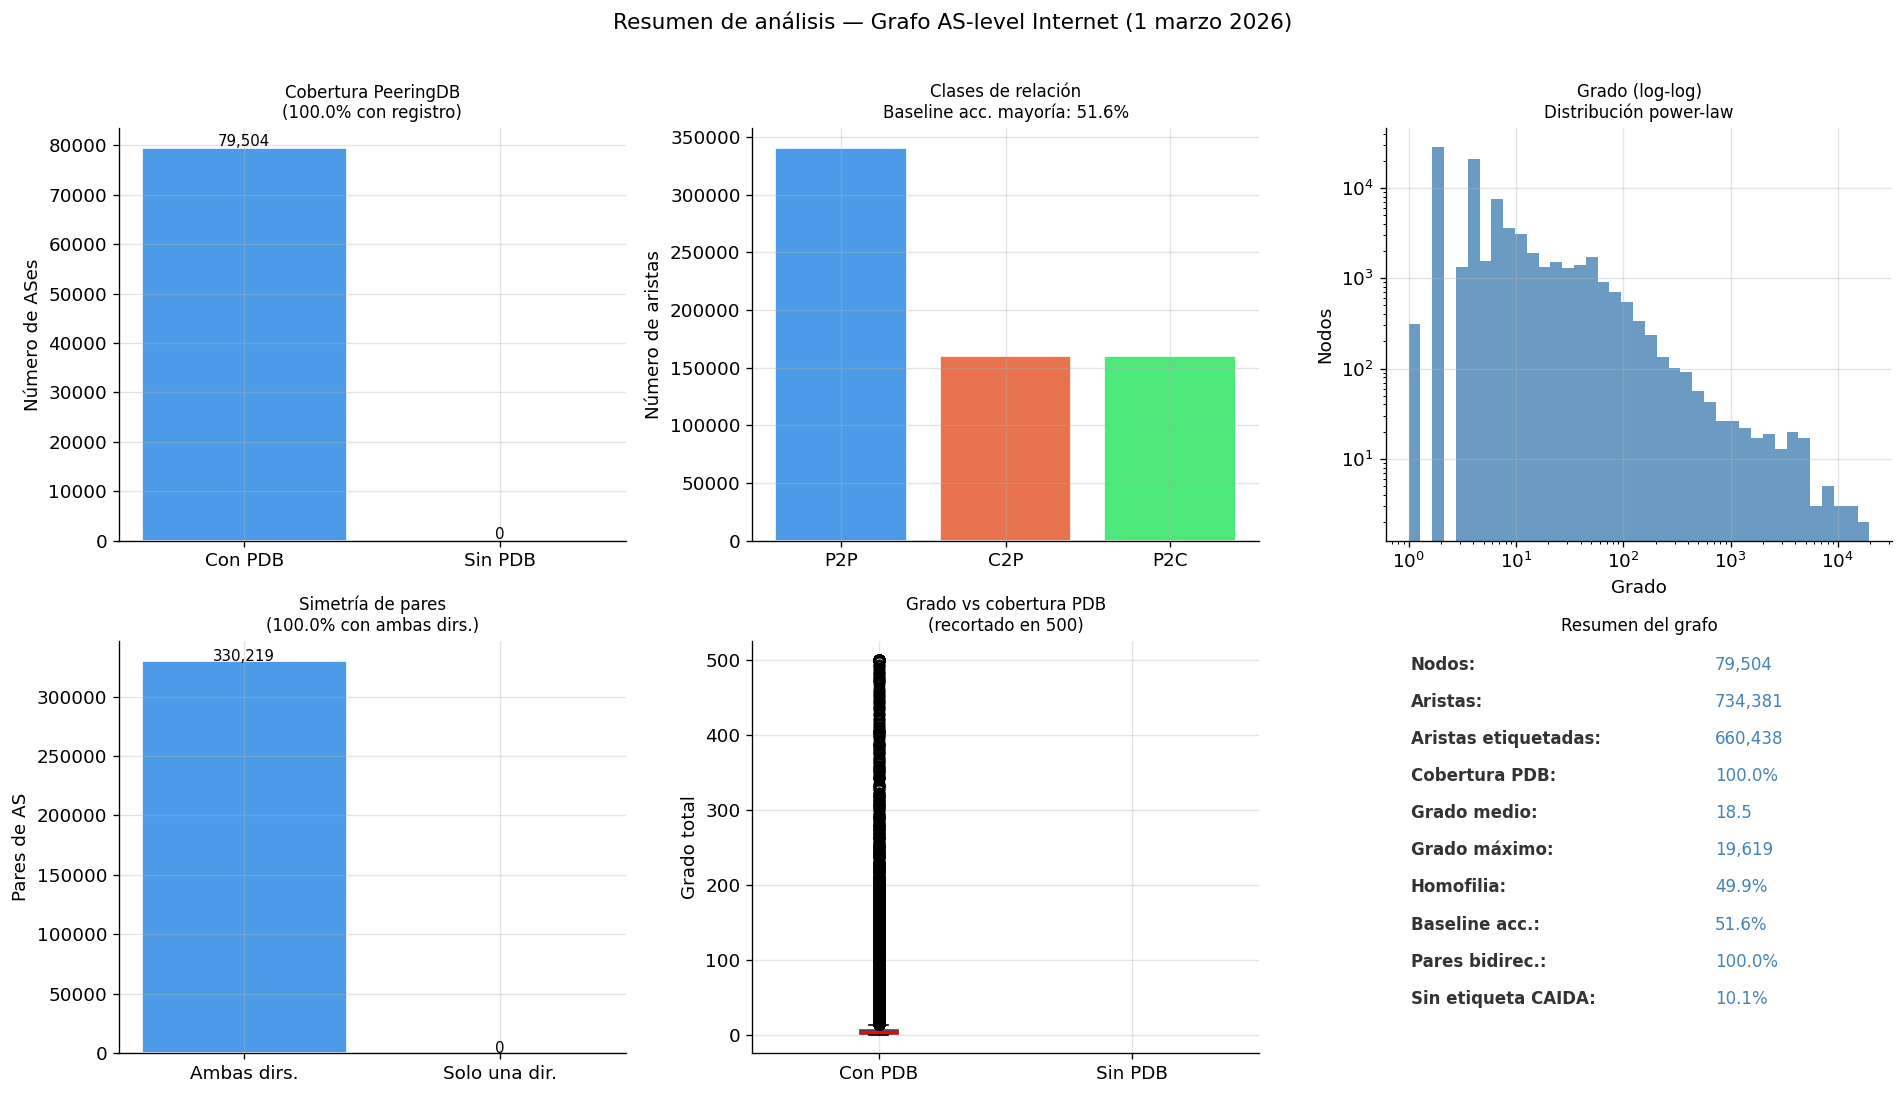


Todas las figuras guardadas en: /home/vale/Escritorio/GIT/TrabajoTesis/notebooks/results/figures/analisis_grafo


In [22]:
# ── Panel visual resumen ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flat

# 1. Cobertura PDB
ax = next(axes)
ax.bar(['Con PDB', 'Sin PDB'], [n_pdb, n_no_pdb],
       color=['#4C9BE8', '#D9534F'], edgecolor='white')
ax.set_title(f'Cobertura PeeringDB\n({100*n_pdb/n_total:.1f}% con registro)', fontsize=10)
ax.set_ylabel('Número de ASes')
for i, v in enumerate([n_pdb, n_no_pdb]):
    ax.text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

# 2. Distribución de clases
ax = next(axes)
ax.bar([LABEL_MAP[k] for k in counts_labeled.index], counts_labeled.values,
       color=[PALETTE[LABEL_MAP[k]] for k in counts_labeled.index], edgecolor='white')
ax.set_title(f'Clases de relación\nBaseline acc. mayoría: {100*majority_class_acc:.1f}%', fontsize=10)
ax.set_ylabel('Número de aristas')

# 3. Distribución de grados (log-log)
ax = next(axes)
bins = np.logspace(0, np.log10(deg_vals.max()+1), 40)
ax.hist(deg_vals, bins=bins, color='steelblue', alpha=0.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Grado (log-log)\nDistribución power-law', fontsize=10)
ax.set_xlabel('Grado'); ax.set_ylabel('Nodos')

# 4. Simetría
ax = next(axes)
ax.bar(['Ambas dirs.', 'Solo una dir.'], [both_dirs, one_dir],
       color=['#4C9BE8', '#F0AD4E'], edgecolor='white')
ax.set_title(f'Simetría de pares\n({100*both_dirs/n_pairs:.1f}% con ambas dirs.)', fontsize=10)
ax.set_ylabel('Pares de AS')
for i, v in enumerate([both_dirs, one_dir]):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# 5. Grado por cobertura PDB
ax = next(axes)
ax.boxplot([deg_pdb.clip(upper=500), deg_nopdb.clip(upper=500)],
           labels=['Con PDB', 'Sin PDB'],
           patch_artist=True,
           boxprops=dict(facecolor='#4C9BE8', alpha=0.7),
           medianprops=dict(color='red', lw=2))
ax.set_title(f'Grado vs cobertura PDB\n(recortado en 500)', fontsize=10)
ax.set_ylabel('Grado total')

# 6. Resumen de métricas clave
ax = next(axes)
ax.axis('off')
metrics = [
    ('Nodos', f'{n_total:,}'),
    ('Aristas', f'{len(edges_df):,}'),
    ('Aristas etiquetadas', f'{len(edges_lab2):,}'),
    ('Cobertura PDB', f'{100*n_pdb/n_total:.1f}%'),
    ('Grado medio', f'{deg_df.total_degree.mean():.1f}'),
    ('Grado máximo', f'{deg_df.total_degree.max():,}'),
    ('Homofilia', f'{100*homo_rate:.1f}%'),
    ('Baseline acc.', f'{100*majority_class_acc:.1f}%'),
    ('Pares bidirec.', f'{100*both_dirs/n_pairs:.1f}%'),
    ('Sin etiqueta CAIDA', f'{100*(edges_df.relationship==-1).mean():.1f}%'),
]
for i, (k, v) in enumerate(metrics):
    ax.text(0.05, 0.93 - i*0.09, f'{k}:', fontsize=10, transform=ax.transAxes,
            fontweight='bold', color='#333333')
    ax.text(0.65, 0.93 - i*0.09, v, fontsize=10, transform=ax.transAxes, color='steelblue')
ax.set_title('Resumen del grafo', fontsize=10)

plt.suptitle('Resumen de análisis — Grafo AS-level Internet (1 marzo 2026)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'resumen_grafo.png', bbox_inches='tight')
plt.show()

print(f'\nTodas las figuras guardadas en: {OUT_DIR.resolve()}')